У цьому ДЗ ми потренуємось розв'язувати задачу багатокласової класифікації за допомогою логістичної регресії з використанням стратегій One-vs-Rest та One-vs-One, оцінити якість моделей та порівняти стратегії.

### Опис задачі і даних

**Контекст**

В цьому ДЗ ми працюємо з даними про сегментацію клієнтів.

Сегментація клієнтів – це практика поділу бази клієнтів на групи індивідів, які схожі між собою за певними критеріями, що мають значення для маркетингу, такими як вік, стать, інтереси та звички у витратах.

Компанії, які використовують сегментацію клієнтів, виходять з того, що кожен клієнт є унікальним і що їхні маркетингові зусилля будуть більш ефективними, якщо вони орієнтуватимуться на конкретні, менші групи зі зверненнями, які ці споживачі вважатимуть доречними та які спонукатимуть їх до купівлі. Компанії також сподіваються отримати глибше розуміння уподобань та потреб своїх клієнтів з метою виявлення того, що кожен сегмент цінує найбільше, щоб точніше адаптувати маркетингові матеріали до цього сегменту.

**Зміст**.

Автомобільна компанія планує вийти на нові ринки зі своїми існуючими продуктами (P1, P2, P3, P4 і P5). Після інтенсивного маркетингового дослідження вони дійшли висновку, що поведінка нового ринку схожа на їхній існуючий ринок.

На своєму існуючому ринку команда з продажу класифікувала всіх клієнтів на 4 сегменти (A, B, C, D). Потім вони здійснювали сегментовані звернення та комунікацію з різними сегментами клієнтів. Ця стратегія працювала для них надзвичайно добре. Вони планують використати ту саму стратегію на нових ринках і визначили 2627 нових потенційних клієнтів.

Ви маєте допомогти менеджеру передбачити правильну групу для нових клієнтів.

В цьому ДЗ використовуємо дані `customer_segmentation_train.csv`[скачати дані](https://drive.google.com/file/d/1VU1y2EwaHkVfr5RZ1U4MPWjeflAusK3w/view?usp=sharing). Це `train.csv`з цього [змагання](https://www.kaggle.com/datasets/abisheksudarshan/customer-segmentation/data?select=train.csv)

**Завдання 1.** Завантажте та підготуйте датасет до аналізу. Виконайте обробку пропущених значень та необхідне кодування категоріальних ознак. Розбийте на тренувальну і тестувальну вибірку, де в тесті 20%. Памʼятаємо, що весь препроцесинг ліпше все ж тренувати на тренувальній вибірці і на тестувальній лише використовувати вже натреновані трансформери.
Але в даному випадку оскільки значень в категоріях небагато, можна зробити обробку і на оригінальних даних, а потім розбити - це простіше. Можна також реалізувати процесинг і тренування моделі з пайплайнами. Обирайте як вам зручніше.

In [147]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

from imblearn.over_sampling import SMOTENC
from imblearn.combine import SMOTETomek

import seaborn as sns
import matplotlib.pyplot as plt

import joblib
import os

from sklearn.decomposition import PCA

In [39]:
train_df = pd.read_csv("../../data/customer_segmentation/customer_segmentation_train.csv")

**Виконуємо EDA**

In [40]:
train_df.head()

,ID,Gender,Ever_Married,Age,Graduated,Profession,Work_Experience,Spending_Score,Family_Size,Var_1,Segmentation
0,462809,Male,No,22,No,Healthcare,1.0,Low,4.0,Cat_4,D
1,462643,Female,Yes,38,Yes,Engineer,NaN,Average,3.0,Cat_4,A
2,466315,Female,Yes,67,Yes,Engineer,1.0,Low,1.0,Cat_6,B
3,461735,Male,Yes,67,Yes,Lawyer,0.0,High,2.0,Cat_6,B
4,462669,Female,Yes,40,Yes,Entertainment,NaN,High,6.0,Cat_6,A


In [41]:
train_df.drop(columns=["ID"], inplace=True)

In [42]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8068 entries, 0 to 8067
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           8068 non-null   object 
 1   Ever_Married     7928 non-null   object 
 2   Age              8068 non-null   int64  
 3   Graduated        7990 non-null   object 
 4   Profession       7944 non-null   object 
 5   Work_Experience  7239 non-null   float64
 6   Spending_Score   8068 non-null   object 
 7   Family_Size      7733 non-null   float64
 8   Var_1            7992 non-null   object 
 9   Segmentation     8068 non-null   object 
dtypes: float64(2), int64(1), object(7)
memory usage: 630.4+ KB


In [43]:
train_df.isnull().sum()

Gender               0
Ever_Married       140
Age                  0
Graduated           78
Profession         124
Work_Experience    829
Spending_Score       0
Family_Size        335
Var_1               76
Segmentation         0
dtype: int64

In [44]:
train_df.describe()

,Age,Work_Experience,Family_Size
count,8068.000000,7239.000000,7733.000000
mean,43.466906,2.641663,2.850123
std,16.711696,3.406763,1.531413
min,18.000000,0.000000,1.000000
25%,30.000000,0.000000,2.000000
50%,40.000000,1.000000,3.000000
75%,53.000000,4.000000,4.000000
max,89.000000,14.000000,9.000000


In [45]:
categorical_cols = ["Gender", "Ever_Married", "Graduated", "Profession", "Spending_Score", "Var_1"]
for col in categorical_cols:
    print(f"{col}:\n{train_df[col].value_counts(dropna=False)}\n")


Gender:
Gender
Male      4417
Female    3651
Name: count, dtype: int64

Ever_Married:
Ever_Married
Yes    4643
No     3285
NaN     140
Name: count, dtype: int64

Graduated:
Graduated
Yes    4968
No     3022
NaN      78
Name: count, dtype: int64

Profession:
Profession
Artist           2516
Healthcare       1332
Entertainment     949
Engineer          699
Doctor            688
Lawyer            623
Executive         599
Marketing         292
Homemaker         246
NaN               124
Name: count, dtype: int64

Spending_Score:
Spending_Score
Low        4878
Average    1974
High       1216
Name: count, dtype: int64

Var_1:
Var_1
Cat_6    5238
Cat_4    1089
Cat_3     822
Cat_2     422
Cat_7     203
Cat_1     133
Cat_5      85
NaN        76
Name: count, dtype: int64



In [50]:
# Заповнення пропущених значень числові - медіана, категоріальні 'missing' небагато пропусків (2–3%)

numeric_cols = train_df.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = train_df.select_dtypes(include=['object']).columns.tolist()

for col in numeric_cols:
    train_df[col] = train_df[col].fillna(train_df[col].median())

for col in categorical_cols:
    train_df[col] = train_df[col].fillna("missing")

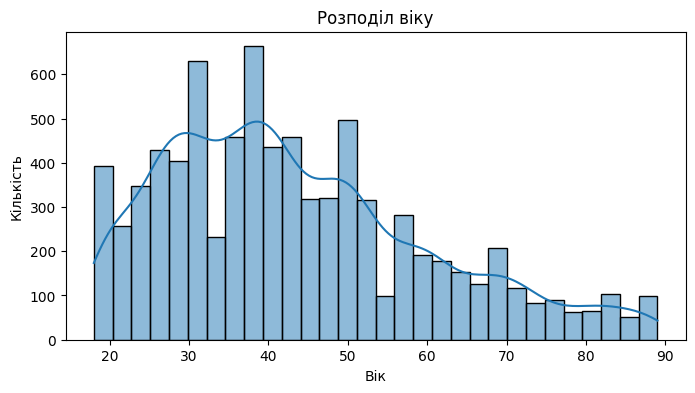

In [51]:
plt.figure(figsize=(8,4))
sns.histplot(train_df["Age"], bins=30, kde=True)
plt.title("Розподіл віку")
plt.xlabel("Вік")
plt.ylabel("Кількість")
plt.show()

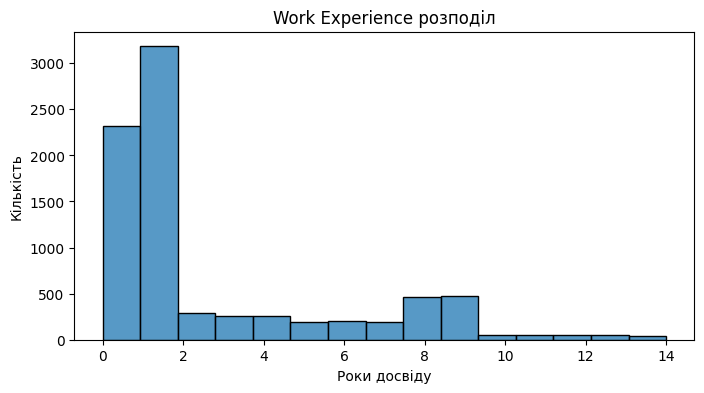

In [52]:
plt.figure(figsize=(8,4))
sns.histplot(train_df["Work_Experience"], bins=15, kde=False)
plt.title("Work Experience розподіл")
plt.xlabel("Роки досвіду")
plt.ylabel("Кількість")
plt.show()

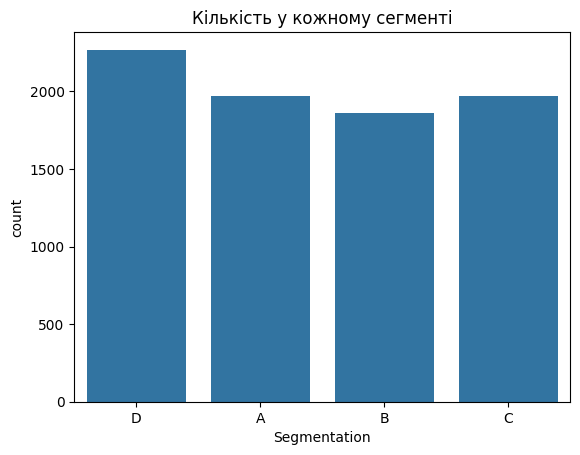

In [53]:
sns.countplot(x="Segmentation", data=train_df)
plt.title("Кількість у кожному сегменті")
plt.show()

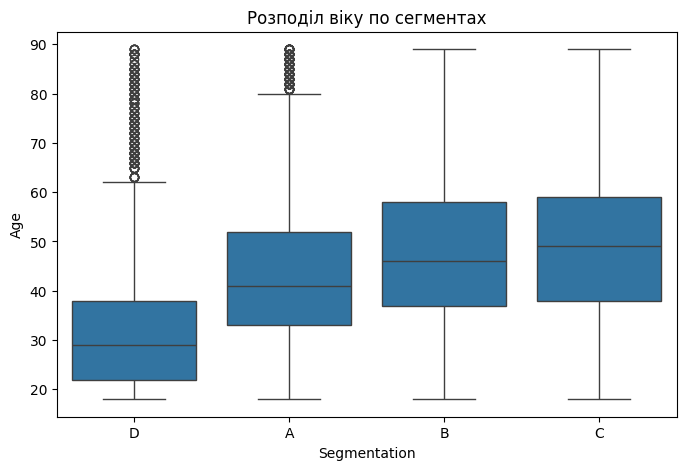

In [54]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Segmentation", y="Age", data=train_df)
plt.title("Розподіл віку по сегментах")
plt.show()

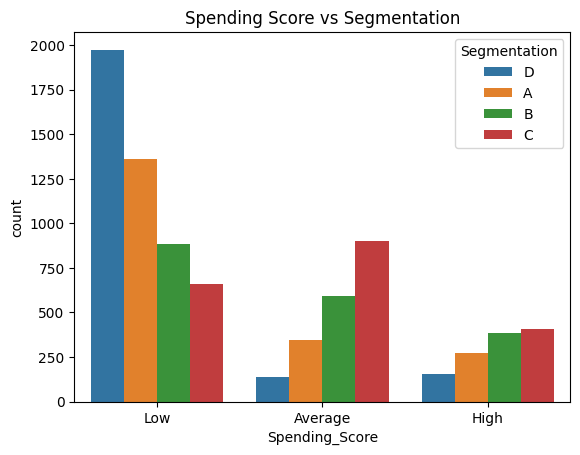

In [55]:
sns.countplot(x="Spending_Score", hue="Segmentation", data=train_df)
plt.title("Spending Score vs Segmentation")
plt.show()

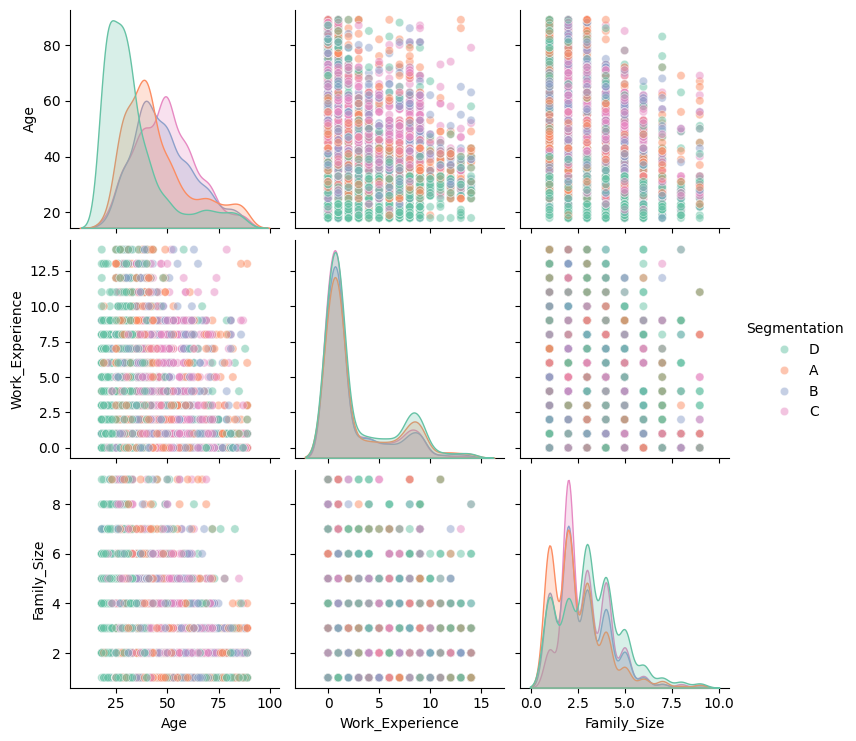

In [56]:
sns.pairplot(
    train_df,
    vars=["Age", "Work_Experience", "Family_Size"],
    hue="Segmentation",
    palette="Set2",
    plot_kws={"alpha": 0.5}
)
plt.show()

1) Age

Розподіл віку зміщений вліво (багато клієнтів молодшого та середнього віку).

У boxplot видно викиди серед літніх клієнтів (за 65+), які можна розглянути на видалення або окремий аналіз.

2) Work_Experience

Більшість клієнтів мають від 0 до 2 років досвіду (помітний пік на гістрограмі).

Є невелика група з високим стажем (10–14 років), але це мало, отже потенційні викиди варто дослідити.

3) Family_Size

Розподіл несиметричний, більшість мають невеликі сім’ї (1–3 людини), але є клієнти із сім’ями 7–9 — їх також можна перевірити на коректність чи викиди.

4) Segmentation

Розподіл класів досить збалансований, особливо між сегментами A, B, C, D — це добре для моделей.

Розподіл Spending_Score по сегментах свідчить про різні патерни поведінки, що варто використати у моделі.

5) Pairplot + Heatmap

Сильних лінійних кореляцій між числовими змінними не спостерігається, ознак мультиколінеарності немає, але є частково кореляція між віком та work_experience (очікувано).

Сегментація чітко виділяється по spending_score і по віку.

In [57]:
def remove_outliers_iqr(df, column, replace_with=None):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    
    mask_outliers = (df[column] < lower) | (df[column] > upper)
    
    n_outliers = mask_outliers.sum()
    print(f"{column}: знайдено {n_outliers} потенційних викидів")
    
    if replace_with is None:
        # видалення
        df_cleaned = df[~mask_outliers].copy()
        return df_cleaned
    else:
        if replace_with == 'median':
            value = df[column].median()
        else:
            value = replace_with
        df.loc[mask_outliers, column] = value
        return df

In [58]:
train_df = remove_outliers_iqr(train_df, 'Age', replace_with=None)

Age: знайдено 71 потенційних викидів


In [59]:
train_df = remove_outliers_iqr(train_df, 'Work_Experience', replace_with=None)

Work_Experience: знайдено 188 потенційних викидів


In [60]:
train_df = remove_outliers_iqr(train_df, 'Family_Size', replace_with=None)

Family_Size: знайдено 89 потенційних викидів


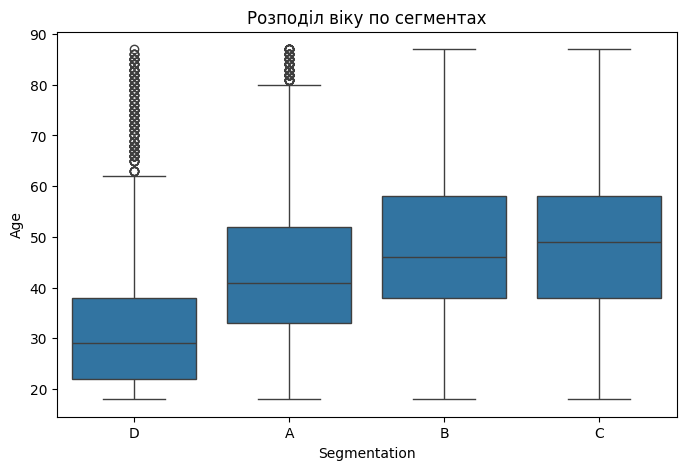

In [61]:
plt.figure(figsize=(8,5))
sns.boxplot(x="Segmentation", y="Age", data=train_df)
plt.title("Розподіл віку по сегментах")
plt.show()

In [112]:
# Пайплайни
X = train_df.drop(columns=["Segmentation"])
y = train_df["Segmentation"]

from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# Визначаємо числові та категоріальні колонки ДО трансформацій
numeric_cols = X_train.select_dtypes(include=['float64', 'int64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()

# Отримуємо індекси категоріальних колонок (для SMOTENC)
cat_feature_indices = [X_train.columns.get_loc(col) for col in categorical_cols]

# Створюємо пайплайн
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

preprocessor.fit(X_train)

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 ['Age', 'Work_Experience', 'Family_Size']),
                                ('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Gender', 'Ever_Married', 'Graduated',
                                  'Profession', 'Spending_Score', 'Var_1'])])

In [113]:
# Збережемо оброблені дані
output_dir = "data_hw_2_4"
os.makedirs(output_dir, exist_ok=True)

# parquet для X/y
X_train.to_parquet("data_hw_2_4/X_train.parquet", index=False)
X_val.to_parquet("data_hw_2_4/X_val.parquet", index=False)
y_train.to_frame().to_parquet("data_hw_2_4/y_train.parquet")
y_val.to_frame().to_parquet("data_hw_2_4/y_val.parquet")

# зберегти fitted ColumnTransformer
joblib.dump(preprocessor, "data_hw_2_4/preprocessor.joblib")

['data_hw_2_4/preprocessor.joblib']

**Завдання 2. Важливо уважно прочитати все формулювання цього завдання до кінця!**

Застосуйте методи ресемплингу даних SMOTE та SMOTE-Tomek з бібліотеки imbalanced-learn до тренувальної вибірки. В результаті у Вас має вийти 2 тренувальних набори: з апсемплингом зі SMOTE, та з ресамплингом з SMOTE-Tomek.

Увага! В нашому наборі даних є як категоріальні дані, так і звичайні числові. Базовий SMOTE не буде правильно працювати з категоріальними даними, але є його модифікація, яка буде. Тому в цього завдання є 2 виконання

  1. Застосувати SMOTE базовий лише на НЕкатегоріальних ознаках.

  2. Переглянути інформацію про метод [SMOTENC](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTENC.html#imblearn.over_sampling.SMOTENC) і використати цей метод в цій задачі. За цей спосіб буде +3 бали за це завдання і він рекомендований для виконання.

  **Підказка**: аби скористатись SMOTENC треба створити змінну, яка містить індекси ознак, які є категоріальними (їх номер серед колонок) і передати при ініціації екземпляра класу `SMOTENC(..., categorical_features=cat_feature_indeces)`.
  
  Ви також можете розглянути варіант використання варіації SMOTE, який працює ЛИШЕ з категоріальними ознаками [SMOTEN](https://imbalanced-learn.org/dev/references/generated/imblearn.over_sampling.SMOTEN.html)

In [114]:
# завантажуємо
X_train = pd.read_parquet("data_hw_2_4/X_train.parquet")
X_val = pd.read_parquet("data_hw_2_4/X_val.parquet")
y_train = pd.read_parquet("data_hw_2_4/y_train.parquet").squeeze()
y_val = pd.read_parquet("data_hw_2_4/y_val.parquet").squeeze()

# підвантажуємо preprocessor
preprocessor = joblib.load("data_hw_2_4/preprocessor.joblib")

In [127]:
X_train_enc = preprocessor.fit_transform(X_train)
X_val_enc = preprocessor.transform(X_val)

In [128]:
# Resampling SMOTENC
from imblearn.over_sampling import SMOTENC

smote_nc = SMOTENC(
    categorical_features=cat_feature_indices,
    random_state=42
)

X_train_resampled, y_train_resampled = smote_nc.fit_resample(X_train, y_train)

print(X_train_resampled.shape)
print(y_train_resampled.value_counts())

(6888, 9)
Segmentation
B    1722
C    1722
A    1722
D    1722
Name: count, dtype: int64


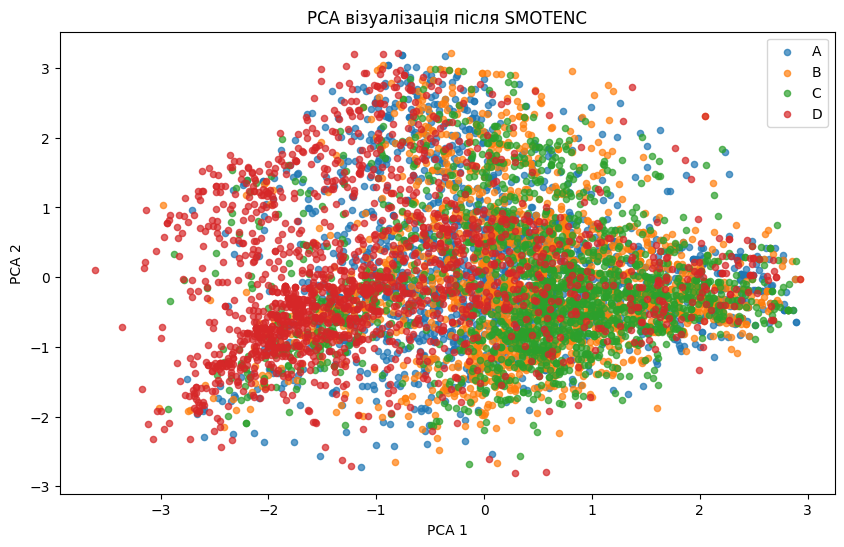

In [129]:
# і тоді вже візуалізація
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_resampled_enc)

plt.figure(figsize=(10,6))
for label in np.unique(y_train_resampled):
    idx = y_train_resampled == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=label, s=20, alpha=0.7)

plt.legend()
plt.title("PCA візуалізація після SMOTENC")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

(5614, 32) Segmentation
C    1449
D    1429
B    1378
A    1358
Name: count, dtype: int64


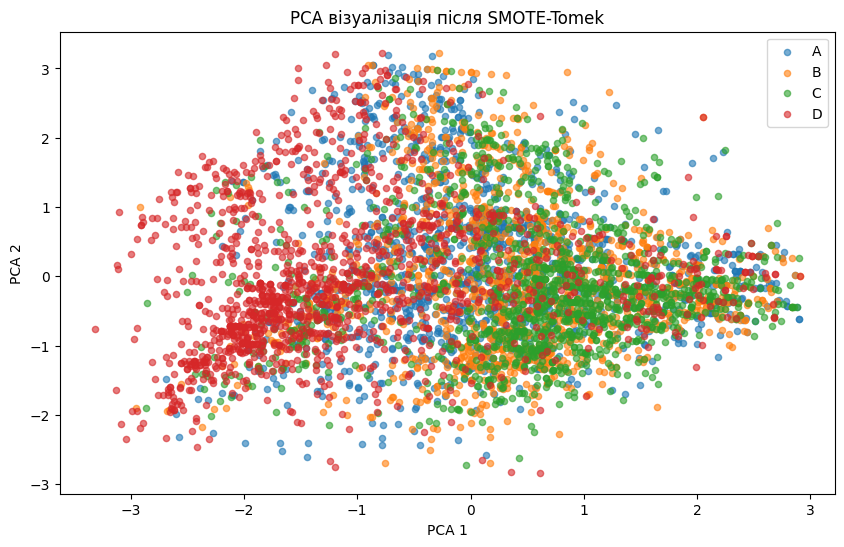

In [130]:
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# 2. fit_transform на X_train
X_train_enc = preprocessor.fit_transform(X_train)
X_val_enc   = preprocessor.transform(X_val)

# 3. SMOTE-Tomek
smote_tomek = SMOTETomek(random_state=42)
X_train_st, y_train_st = smote_tomek.fit_resample(X_train_enc, y_train)

# 4. перевірка
print(X_train_st.shape, y_train_st.value_counts())

# 5. PCA-візуалізація
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_st)

plt.figure(figsize=(10,6))
for label in np.unique(y_train_st):
    idx = y_train_st == label
    plt.scatter(X_pca[idx, 0], X_pca[idx, 1], label=label, alpha=0.6, s=20)
plt.legend()
plt.title("PCA візуалізація після SMOTE-Tomek")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

**Завдання 3**.
  1. Навчіть модель логістичної регресії з використанням стратегії One-vs-Rest з логістичною регресією на оригінальних даних, збалансованих з SMOTE, збалансованих з Smote-Tomek.  
  2. Виміряйте якість кожної з натренованих моделей використовуючи `sklearn.metrics.classification_report`.
  3. Напишіть, яку метрику ви обрали для порівняння моделей.
  4. Яка модель найкраща?
  5. Якщо немає суттєвої різниці між моделями - напишіть свою гіпотезу, чому?

In [140]:
X_train_resampled_enc = preprocessor.transform(X_train_resampled)

model_orig  = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
model_smote = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))
model_st    = OneVsRestClassifier(LogisticRegression(max_iter=1000, random_state=42))

# тренуємо
model_orig.fit(X_train_enc, y_train)
y_pred_orig = model_orig.predict(X_val_enc)

model_smote.fit(X_train_resampled_enc, y_train_resampled)
y_pred_smote = model_smote.predict(X_val_enc)

model_st.fit(X_train_st, y_train_st)
y_pred_st = model_st.predict(X_val_enc)

# Прогноз
y_pred_orig = model_orig.predict(X_val_enc)
y_pred_smote = model_smote.predict(X_val_enc)
y_pred_st = model_st.predict(X_val_enc)

# Якість
print("Оригінальні дані:\n", classification_report(y_val, y_pred_orig))
print("SMOTE:\n", classification_report(y_val, y_pred_smote))
print("SMOTE-Tomek:\n", classification_report(y_val, y_pred_st))

Оригінальні дані:
               precision    recall  f1-score   support

           A       0.41      0.50      0.45       373
           B       0.39      0.13      0.20       360
           C       0.52      0.67      0.59       381
           D       0.66      0.73      0.69       430

    accuracy                           0.52      1544
   macro avg       0.49      0.51      0.48      1544
weighted avg       0.50      0.52      0.49      1544

SMOTE:
               precision    recall  f1-score   support

           A       0.41      0.51      0.45       373
           B       0.39      0.23      0.28       360
           C       0.54      0.61      0.58       381
           D       0.67      0.68      0.68       430

    accuracy                           0.52      1544
   macro avg       0.50      0.51      0.50      1544
weighted avg       0.51      0.52      0.51      1544

SMOTE-Tomek:
               precision    recall  f1-score   support

           A       0.41      0.54 

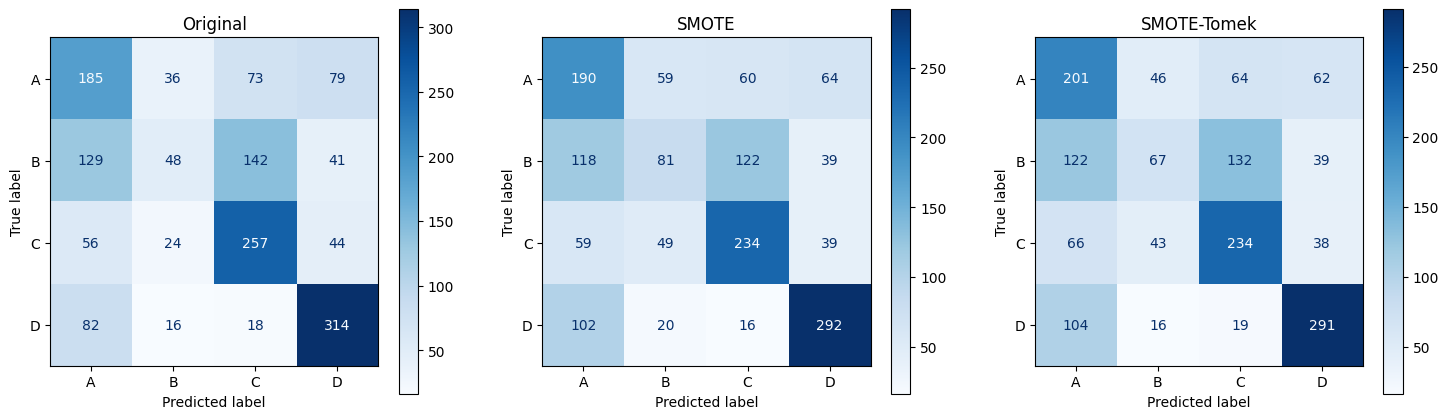

In [143]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

# 1. оригінальні
ConfusionMatrixDisplay.from_estimator(model_orig, X_val_enc, y_val, ax=axes[0], cmap="Blues")
axes[0].set_title("Original")

# 2. SMOTE
ConfusionMatrixDisplay.from_estimator(model_smote, X_val_enc, y_val, ax=axes[1], cmap="Blues")
axes[1].set_title("SMOTE")

# 3. SMOTE-Tomek
ConfusionMatrixDisplay.from_estimator(model_st, X_val_enc, y_val, ax=axes[2], cmap="Blues")
axes[2].set_title("SMOTE-Tomek")

plt.show()

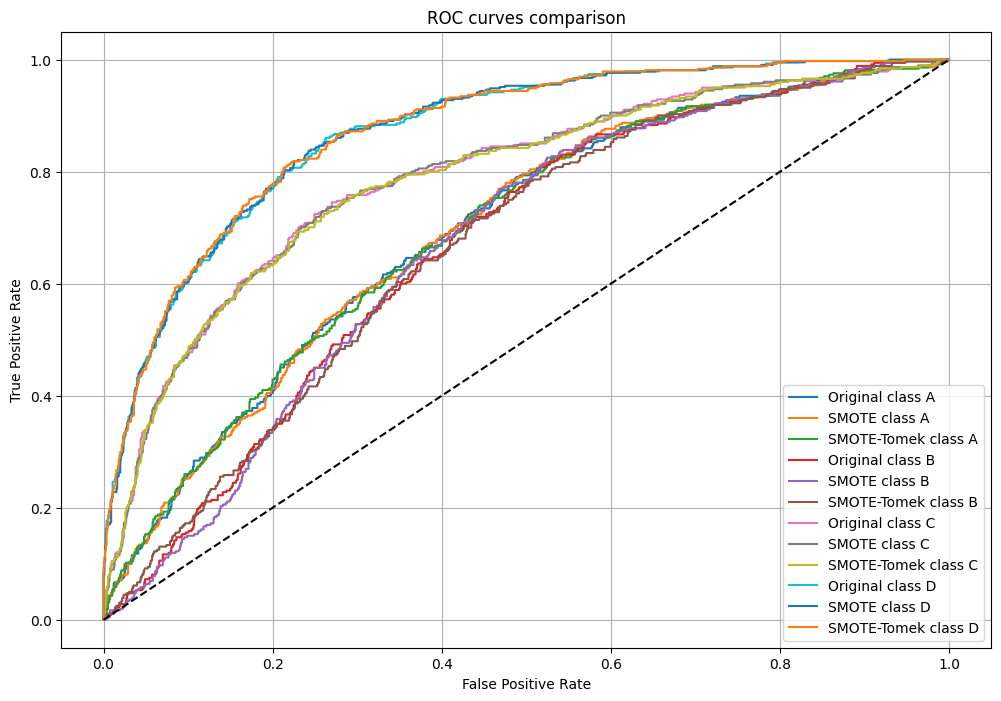

In [148]:
# бінаризуємо y для багатокласового ROC
y_val_bin = label_binarize(y_val, classes=model_orig.classes_)
n_classes = y_val_bin.shape[1]

# ймовірності для кожної моделі
y_score_orig  = model_orig.decision_function(X_val_enc)
y_score_smote = model_smote.decision_function(X_val_enc)
y_score_st    = model_st.decision_function(X_val_enc)

plt.figure(figsize=(12,8))

for i in range(n_classes):
    fpr_o, tpr_o, _ = roc_curve(y_val_bin[:, i], y_score_orig[:, i])
    fpr_s, tpr_s, _ = roc_curve(y_val_bin[:, i], y_score_smote[:, i])
    fpr_t, tpr_t, _ = roc_curve(y_val_bin[:, i], y_score_st[:, i])
    
    plt.plot(fpr_o, tpr_o, label=f'Original class {model_orig.classes_[i]}')
    plt.plot(fpr_s, tpr_s, label=f'SMOTE class {model_orig.classes_[i]}')
    plt.plot(fpr_t, tpr_t, label=f'SMOTE-Tomek class {model_orig.classes_[i]}')

plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curves comparison')
plt.legend()
plt.grid()
plt.show()

**Висновки**

Метріка для порівняння
- F1-score (із classification_report) — оскільки дані незбалансовані, F1 дає кращу оцінку, ніж просто accuracy
- ROC-AUC — для мультикласових кривих ROC, щоб додатково перевірити дискримінацію кожного класу

Яка модель найкраща

Ррізниця між SMOTE і SMOTE-Tomek мінімальна

Можливо дисбаланс у даних не був критичним, і модель достатньо стійка до нього

SMOTE і SMOTE-Tomek допомогли трохи покращити recall для менш представлених класів, але самі ознаки і модель не дозволяють радикально змінити якість